# Computer Vision 1: Assignment 2

Task 2

Group Number 43

Marek Drwal

01.12.2025

## setup

In [31]:
import numpy as np
import skimage as ski
import matplotlib.pyplot as plt

## defs

In [32]:
def show_img(img, pth='', comment=''):
    plt.imshow(img, cmap=plt.cm.gray)
    plt.title(comment + pth)
    plt.show()

In [33]:
def load_display_img(pth, is_gray=False):
    img = ski.io.imread(pth)
    if not is_gray:
        show_img(img, pth, 'org ')
        img = ski.color.rgb2gray(img)
    show_img(img, pth, 'gray ')
    return img

In [34]:
def augment_img(img, pth='', display=True):
    N = ski.util.random_noise(img, 'gaussian', var=0.01, rng=123)
    show_img(N, pth, 'noise ')
    S = ski.filters.gaussian(N, sigma=1)
    show_img(S, pth, 'smooth ')
    FN = ski.filters.sobel(N)
    show_img(FN, pth, 'Sobel on noise ')
    FS = ski.filters.sobel(S)
    show_img(FS, pth, 'Sobel on smooth ')
    return N, S, FN, FS

In [35]:
def plot_img_hist(img, no_bins=500):
    return plt.hist(img.ravel(), bins=no_bins, range=(0,1), histtype='step')

## the woman

In [36]:
pth = 'woman.png'

### imgs

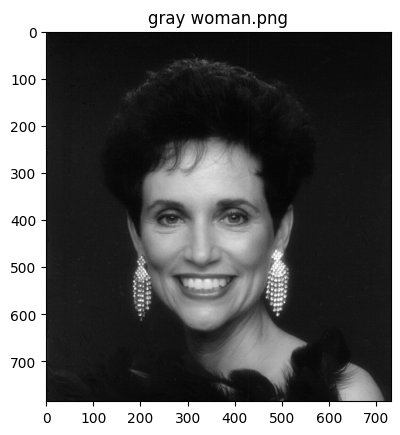

In [37]:
woman = load_display_img(pth, is_gray=True)

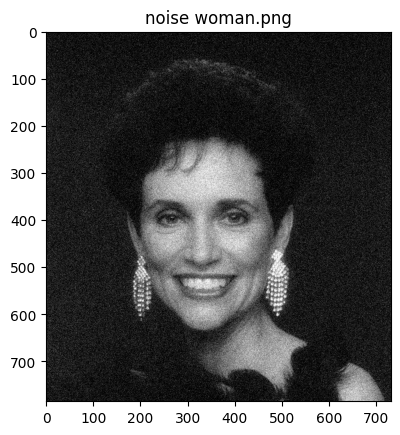

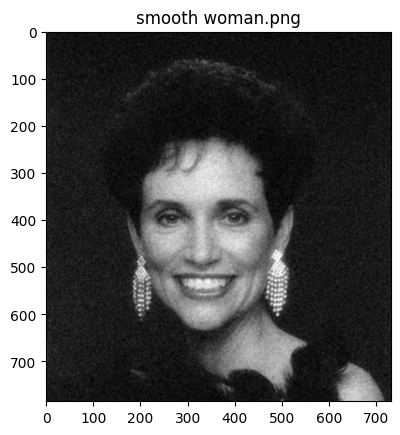

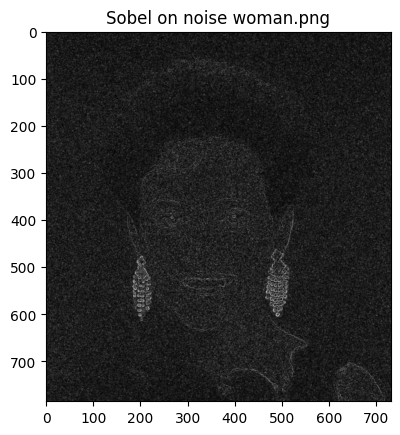

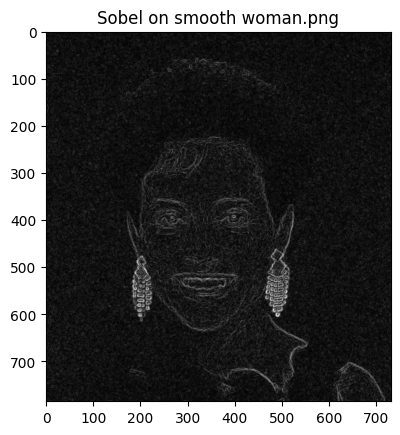

In [38]:
N, S, FN, FS = augment_img(woman, pth)

### histograms

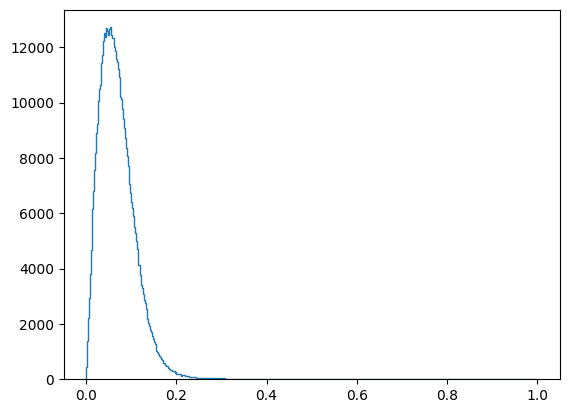

In [39]:
hist_N = plot_img_hist(FN)

In [40]:
tn = 0.17

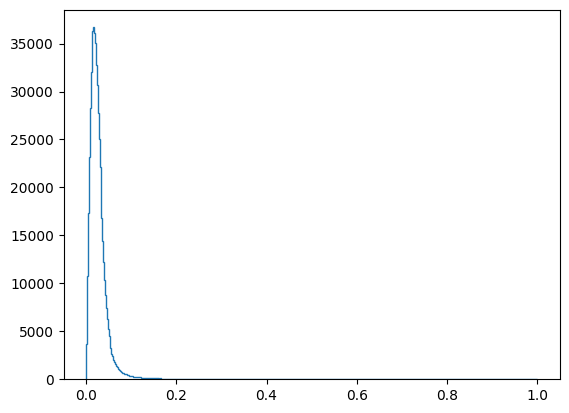

In [41]:
hist_S = plot_img_hist(FS)

In [42]:
ts = 0.075

### binary masks

In [97]:
masked_FN = np.where(FN.ravel() > tn, True, False)
masked_FN = masked_FN.reshape(FS.shape)
masked_FN

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [ True, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [ True, False, False, ..., False, False, False]])

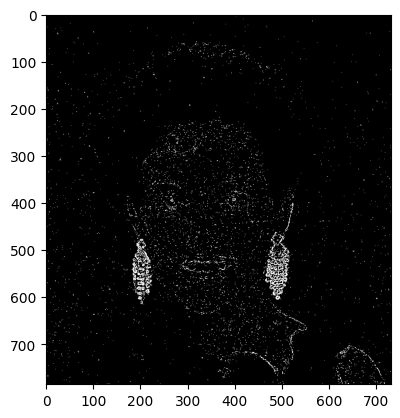

In [98]:
plt.imshow(masked_FN, cmap=plt.cm.gray)

In [99]:
masked_FS = np.where(FS.ravel() > ts, True, False)
masked_FS = masked_FS.reshape(FS.shape)
masked_FS

array([[False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       ...,
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False],
       [False, False, False, ..., False, False, False]])

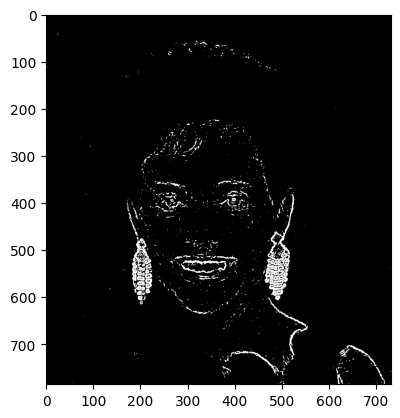

In [100]:
plt.imshow(masked_FS, cmap=plt.cm.gray)

 Why is edge detection improved by applying smoothing?

## TRUDI

#### 022

In [ ]:
pth = '0222.jpg'